# Synthetic Ground-Truth Training — Soft-DTW (Deistler Recipe)

Validation experiment: generate a voltage trace from **known** AdEx parameters,
then attempt to recover those parameters via gradient-based training.

This notebook uses **soft dynamic time warping (soft-DTW)** as the training loss,
with the preprocessing from Deistler et al. (supplement, DTW section):

1. Sliding-window max reduction (window=50, stride=30 at dt=0.025 ms) — compresses
   time points while preserving spike geometry.
2. Rescale observations and simulations to the unit interval using the **same**
   scaling factors (derived from the target trace).
3. Cost function `c(x_i, y_j) = |x_i − y_j| + λ · |i − j|` — L1 amplitude error plus
   a temporal penalty that encourages pointwise alignment.

**Setup:**
- Ground truth parameters: Naud "tonic" set (configurable)
- Current stimulus: synthetic step current
- Initial parameters: ~15% perturbation from ground truth
- Single-stage training: Soft-DTW on preprocessed voltage traces

In [1]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config
from jax.scipy.special import logsumexp

from ADoptEX.core.data import TraceData
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import inject_spike_peaks
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_stim_window_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 43

## 1. Ground Truth Parameters & Current Stimulus

Build a synthetic step-current stimulus (independent of experimental sampling),
then define ground truth AdEx parameters. The Deistler preprocessing is tuned
for `dt_ms = 0.025` (window size 50 ≈ 1.25 ms, stride 30 ≈ 0.75 ms).

In [2]:
# --- Synthetic step-current waveform ---
# dt_ms=0.025 matches the Deistler DTW recipe (window=50 ts, stride=30 ts).
dt_ms = 0.025
t_max_ms = 100.0
stim_delay_ms = 5.0
stim_duration_ms = 95.0
stim_current_pA = 415.0

n_samples = int(round(t_max_ms / dt_ms))
time_arr = np.arange(n_samples) * dt_ms
current_arr = np.zeros(n_samples)
stim_start_idx = int(round(stim_delay_ms / dt_ms))
stim_end_idx = int(round((stim_delay_ms + stim_duration_ms) / dt_ms))
current_arr[stim_start_idx:stim_end_idx] = stim_current_pA

exp_cropped = TraceData(
    time=time_arr,
    voltage=np.zeros(n_samples),  # placeholder; GT voltage is simulated below
    current=current_arr,
    dt_ms=dt_ms,
    spike_times=np.array([]),
    stim_start_idx=stim_start_idx,
    stim_end_idx=stim_end_idx,
    stim_current_pA=float(stim_current_pA),
)

print(f"Current waveform: {exp_cropped.n_samples} samples, dt={exp_cropped.dt_ms:.3f} ms")
print(f"Stim window: idx {exp_cropped.stim_start_idx} - {exp_cropped.stim_end_idx} ({exp_cropped.stim_duration_ms:.1f} ms)")
print(f"Stim current: {exp_cropped.stim_current_pA:.1f} pA")

Current waveform: 4000 samples, dt=0.025 ms
Stim window: idx 200 - 4000 (95.0 ms)
Stim current: 415.0 pA


In [3]:
# --- Ground truth parameters (change this to test different regimes) ---
GROUND_TRUTH_BASE = "adaptation"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
ground_truth_params["v_threshold"] = 0.0
ground_truth_params["delta_T"] = 3.0

# Override values that would sit at parameter bounds (which prevents perturbation
# and makes recovery trivial/impossible). Choose values well inside PARAM_BOUNDS.
ground_truth_params["v_reset"] = -58.0   # bounds: [-60, -45], midpoint -52.5
ground_truth_params["E_L"] = -72.0       # bounds: [-75, -68], midpoint -71.5
ground_truth_params["v_T"] = -45.0       # bounds: [-60, -30], well inside
ground_truth_params["tau_w"] = 200.0     # bounds: [20, 320], well inside

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: adaptation
Ground truth parameters:
  C_m             200.000  [10.0, 240.0]  (83% into range)
  g_L              12.000  [6.0, 14.0]  (75% into range)
  E_L             -72.000  [-110.0, -65.0]  (84% into range)
  v_T             -45.000  [-60.0, -35.0]  (60% into range)
  delta_T           3.000  [1, 20.0]  (11% into range)
  v_reset         -58.000  [-80.0, -45.0]  (63% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w           200.000  [20.0, 320.0]  (60% into range)
  a                 2.000  [-5.0, 5.0]  (70% into range)
  b                60.000  [0.0, 65.0]  (92% into range)
  I               500.000


## 2. Generate Synthetic Voltage Trace

Simulate with ground truth parameters and the synthetic current waveform,
then package the result as `TraceData` (same structure as experimental data).

INFO:2026-04-22 09:22:35,980:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Ground truth simulation: 2 spikes, 20.0 Hz

Synthetic TraceData: 4000 samples, 2 spikes
Spike times: [39.3 80.9] ms
Stim window: idx 200 - 4000 (95.0 ms)


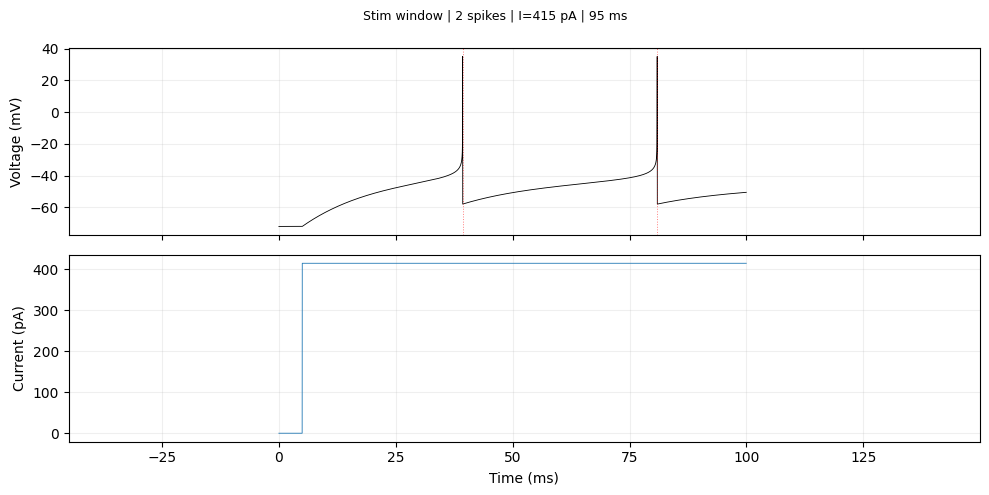

In [4]:
# --- Simulate ground truth ---
# IMPORTANT: use_surrogate=True so the forward pass matches the training cell exactly.
# AdEx uses jax.lax.select (boolean), AdExSurrogate uses arithmetic blend (s*a + (1-s)*b).
# Even though both produce 0/1 spikes, floating-point differences accumulate over 4000
# timesteps and cause a significant loss floor if mismatched.
sim_gt = simulate_with_current_trace(
    params=ground_truth_params,
    current_trace_pA=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    use_surrogate=False,
)

print(f"Ground truth simulation: {sim_gt.n_spikes} spikes, {sim_gt.firing_rate_hz:.1f} Hz")

# --- Package as TraceData (same structure as experimental data) ---
# Jaxley may return one extra timestep; truncate to match the input current length
n = len(exp_cropped.time)
voltage_gt = sim_gt.voltage[:n].copy()

# Use spike times from the simulation's internal spike trace, NOT from detect_spikes().
# Jaxley resets voltage within the same timestep, so the recorded voltage never crosses
# the detection threshold — but the spike indicator is set correctly.
spike_times = sim_gt.spike_times

# Inject spike peaks into the target voltage trace so the sliding-window max sees real
# peaks (Jaxley resets within the spike timestep, so the raw recorded voltage never
# reaches the peak). During training we inject the same peak into the simulated trace
# from the soft spike indicator — see make_soft_dtw_loss_fn below.
SPIKE_PEAK_MV = 35.0
for st in spike_times:
    idx = int(st / exp_cropped.dt_ms)
    if 0 <= idx < len(voltage_gt):
        voltage_gt[idx] = SPIKE_PEAK_MV

data = TraceData(
    time=exp_cropped.time,
    voltage=voltage_gt,
    current=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    spike_times=spike_times,
    stim_start_idx=exp_cropped.stim_start_idx,
    stim_end_idx=exp_cropped.stim_end_idx,
    stim_current_pA=exp_cropped.stim_current_pA,
)

print(f"\nSynthetic TraceData: {data.n_samples} samples, {data.n_spikes} spikes")
print(f"Spike times: {data.spike_times.round(1)} ms")
print(f"Stim window: idx {data.stim_start_idx} - {data.stim_end_idx} ({data.stim_duration_ms:.1f} ms)")

trace_stim_window_plot(data);

## 3. Perturbed Initial Parameters

Create initial parameters by adding ~15% noise to the ground truth.
This simulates the real scenario where we don't know the true values.

In [5]:
PERTURBATION = 0.0  # relative perturbation

TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T"]


def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = list(set(TRAINABLE_STAGE1))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
E_L               -72.000      -72.000     0.0%
delta_T             3.000        3.000     0.0%
C_m               200.000      200.000     0.0%
v_reset           -58.000      -58.000     0.0%
g_L                12.000       12.000     0.0%
v_T               -45.000      -45.000     0.0%


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Initial simulation: 2 spikes (target: 2)
Gamma = 1.000


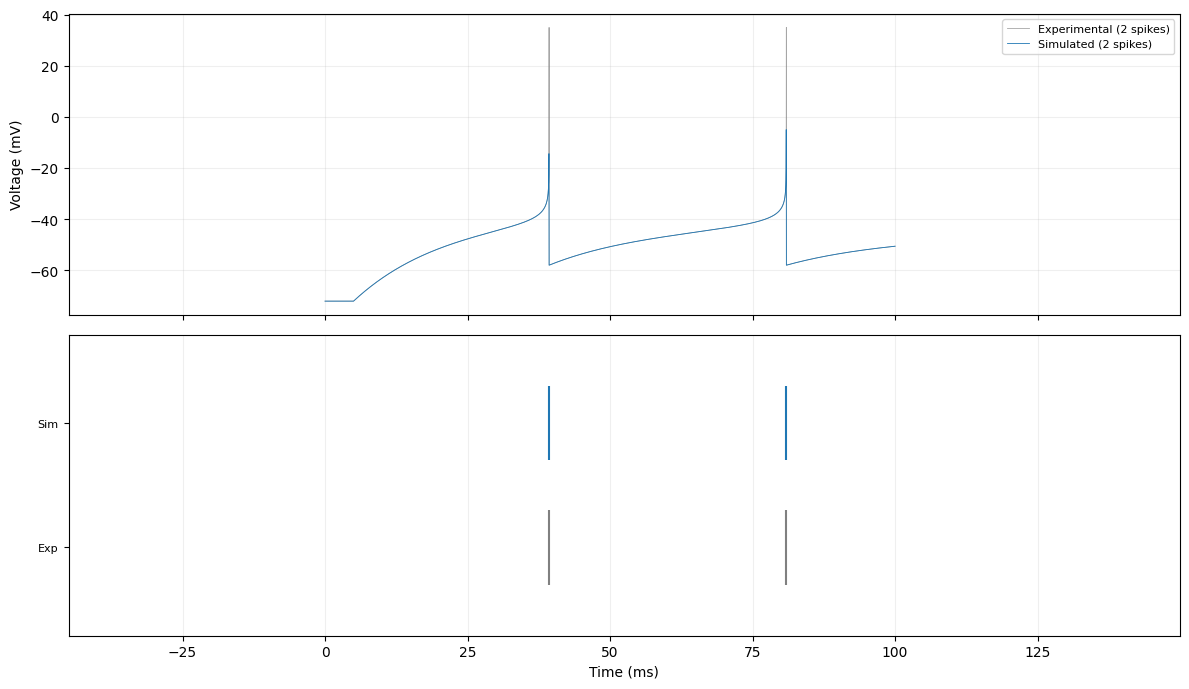

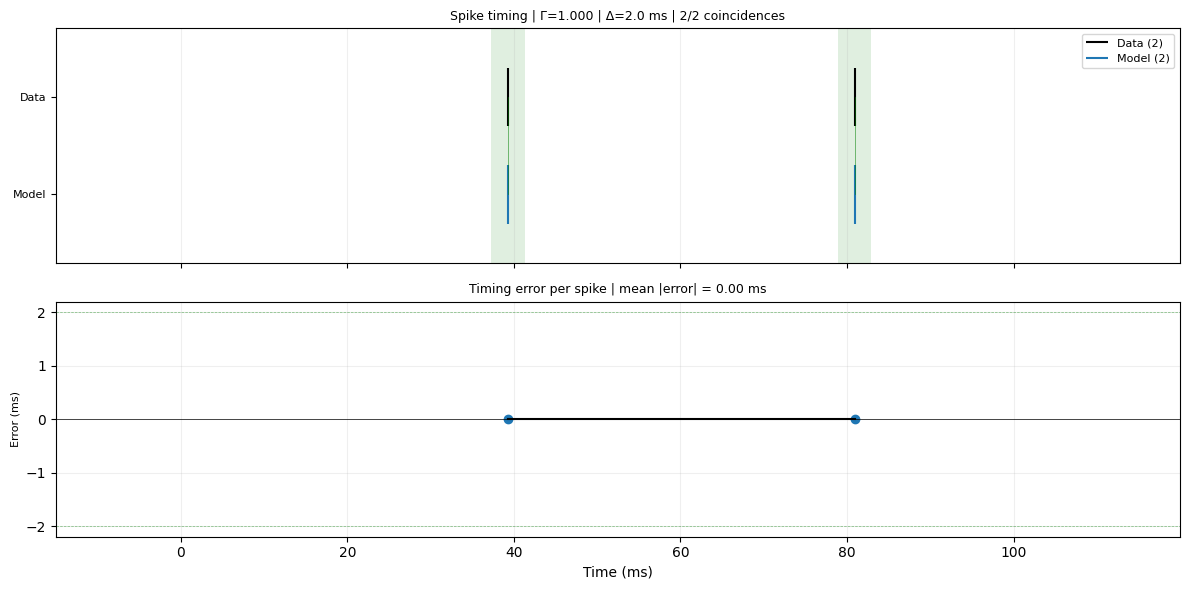

In [6]:
# Simulate with perturbed initial parameters to see the starting point
sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")

if sim_init.n_spikes > 0 and data.n_spikes > 0:
    cf_s0 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_init.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s0.gamma:.3f}")
else:
    cf_s0 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_init);

if cf_s0 is not None:
    spike_timing_plot(data, sim_init, cf_s0);

## 4. Soft-DTW Loss with Deistler Preprocessing

Implementation of the soft-DTW recipe from Deistler et al. supplements:

- **Sliding-window max**: reduces a 4000-sample voltage trace (dt=0.025 ms) to ~133
  samples using `jax.lax.reduce_window` (window=50, stride=30). Differentiable.
- **Unit rescaling**: both traces scaled by the *target's* min/max, so the scaling is
  consistent across the training loop.
- **Cost matrix**: `C[i,j] = |x_i − y_j| + λ · |i − j|` — L1 amplitude error plus
  temporal penalty that discourages warping paths far from the diagonal.
- **Soft-DTW**: standard DP with soft-minimum `softmin_γ(v) = −γ · logsumexp(−v/γ)`,
  computed row-by-row via `jax.lax.scan` (differentiable via JAX's autodiff).

In [7]:
# --- Deistler preprocessing ---
def sliding_window_max(v: jnp.ndarray, window_size: int, stride: int) -> jnp.ndarray:
    """Sliding-window max reduction via jax.lax.reduce_window (differentiable)."""
    return jax.lax.reduce_window(
        v,
        init_value=-jnp.inf,
        computation=jax.lax.max,
        window_dimensions=(window_size,),
        window_strides=(stride,),
        padding="VALID",
    )


def rescale_unit(v: jnp.ndarray, v_min: float, v_max: float, eps: float = 1e-8) -> jnp.ndarray:
    """Rescale to [0, 1] using pre-computed min/max (shared across sim and target)."""
    return (v - v_min) / (v_max - v_min + eps)


# --- Soft-DTW ---
_LARGE = 1e9  # stand-in for +inf; softmin treats -_LARGE/gamma as negligible


def _softmin(values: jnp.ndarray, gamma: float) -> jnp.ndarray:
    return -gamma * logsumexp(-values / gamma)


def soft_dtw_from_cost(C: jnp.ndarray, gamma: float = 1.0) -> jnp.ndarray:
    """Soft-DTW distance from a pre-built cost matrix C of shape (n, m).

    R[0, 0] = 0; R[0, j>0] = R[i>0, 0] = +inf (approximated by _LARGE).
    R[i, j] = C[i-1, j-1] + softmin_gamma(R[i-1, j-1], R[i-1, j], R[i, j-1]).
    Returns R[n, m].
    """
    n, m = C.shape

    def process_row(R_prev: jnp.ndarray, C_row: jnp.ndarray):
        # R_prev has shape (m+1,); C_row has shape (m,).
        def col_step(R_curr_prev, inputs):
            R_diag, R_up, C_val = inputs
            R_curr = C_val + _softmin(jnp.stack([R_diag, R_up, R_curr_prev]), gamma)
            return R_curr, R_curr

        col_inputs = (R_prev[:-1], R_prev[1:], C_row)
        _, R_curr_rest = jax.lax.scan(col_step, _LARGE, col_inputs)
        R_curr = jnp.concatenate([jnp.array([_LARGE]), R_curr_rest])
        return R_curr, None

    R_init = jnp.concatenate([jnp.zeros(1), jnp.full(m, _LARGE)])
    R_final, _ = jax.lax.scan(process_row, R_init, C)
    return R_final[-1]


# Quick sanity check on toy sequences
_toy_x = jnp.array([0.0, 1.0, 2.0, 1.0, 0.0])
_toy_y = jnp.array([0.0, 1.0, 2.0, 1.0, 0.0])
_i, _j = jnp.arange(5)[:, None], jnp.arange(5)[None, :]
_C = jnp.abs(_toy_x[:, None] - _toy_y[None, :]) + jnp.abs(_i - _j)
print(f"Soft-DTW(identical, gamma=1.0) ≈ {float(soft_dtw_from_cost(_C, gamma=1.0)):.4f} (should be near 0)")

Soft-DTW(identical, gamma=1.0) ≈ -1.0337 (should be near 0)


In [8]:
# --- Soft-DTW loss factory (Deistler preprocessing + divergence form) ---
def make_soft_dtw_loss_fn(
    cell,
    data_stimuli,
    t_max: float,
    dt_ms: float,
    exp_voltage: jnp.ndarray,
    stim_end_index: int,
    *,
    window_size: int = 50,
    stride: int = 30,
    gamma: float = 0.5,
    lambda_temp: float = 10.0,
    spike_peak_mv: float | None = 35.0,
    use_divergence: bool = True,
):
    """Build a closure `params -> scalar loss` computing soft-DTW on the
    sliding-window-max-reduced, unit-rescaled voltage traces with an L1 +
    (normalized) temporal-penalty cost.

    Cost: C[i, j] = |x_i - y_j| + lambda_temp * |i - j| / (n - 1)
    Both terms live in [0, 1], so lambda_temp directly controls timing vs. amplitude.

    If `use_divergence=True` (default), returns the Cuturi & Blondel soft-DTW
    divergence D(x, y) = sdtw(x, y) - 0.5 * (sdtw(x, x) + sdtw(y, y)), which is
    non-negative and = 0 when x = y. This removes soft-DTW's intrinsic length-
    dependent bias (~gamma * log(3) per cell) that otherwise pushes the loss
    to large negative values, confusingly making a "better" fit look "worse".
    """
    import jaxley as jx

    exp_v = jnp.asarray(exp_voltage)

    # Precompute target preprocessing (static across training).
    exp_reduced = sliding_window_max(exp_v, window_size, stride)
    # Scale using the *reduced* target's min/max so the rescaled target covers [0, 1].
    v_min = float(jnp.min(exp_reduced))
    v_max = float(jnp.max(exp_reduced))
    exp_scaled = rescale_unit(exp_reduced, v_min, v_max)
    m = exp_scaled.shape[0]

    # Precompute sdtw(y, y) — constant baseline used by the divergence form.
    if use_divergence:
        j_idx_y = jnp.arange(m, dtype=exp_scaled.dtype)
        denom_y = jnp.maximum(jnp.asarray(m - 1, dtype=exp_scaled.dtype), 1.0)
        C_yy = jnp.abs(exp_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(j_idx_y[:, None] - j_idx_y[None, :]) / denom_y
        )
        sdtw_yy = soft_dtw_from_cost(C_yy, gamma=gamma)
    else:
        sdtw_yy = jnp.asarray(0.0, dtype=exp_scaled.dtype)

    def loss_fn(params):
        results = jx.integrate(
            cell,
            params=params,
            data_stimuli=data_stimuli,
            delta_t=dt_ms,
            t_max=t_max,
        )
        voltage = results[0].flatten()
        min_len = min(len(voltage), len(exp_v))
        sim_v = voltage[:min_len]

        # Hard-inject peaks at spike timesteps (results[2] is 0/1 in the forward
        # pass from AdExSurrogate's Heaviside). Mirrors the manual injection on
        # the target trace so the sliding-window max sees the same peak height.
        if spike_peak_mv is not None:
            spikes = results[2].flatten()[:min_len]
            sim_v = inject_spike_peaks(sim_v, spikes, spike_peak_mv)

        sim_reduced = sliding_window_max(sim_v, window_size, stride)
        sim_scaled = rescale_unit(sim_reduced, v_min, v_max)
        n = sim_scaled.shape[0]

        denom = jnp.maximum(jnp.asarray(max(n, m) - 1, dtype=exp_scaled.dtype), 1.0)
        i_idx = jnp.arange(n, dtype=exp_scaled.dtype)[:, None]
        j_idx = jnp.arange(m, dtype=exp_scaled.dtype)[None, :]
        C_xy = jnp.abs(sim_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_idx - j_idx) / denom
        )
        sdtw_xy = soft_dtw_from_cost(C_xy, gamma=gamma)

        if not use_divergence:
            return sdtw_xy

        # sdtw(x, x): full cost (amplitude + temporal), same form as C_yy.
        # Using only the temporal penalty here would make sdtw(x, x) != sdtw(y, y)
        # even when x == y, breaking the divergence identity D(x, x) = 0.
        i_only = jnp.arange(n, dtype=exp_scaled.dtype)
        C_xx = jnp.abs(sim_scaled[:, None] - sim_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_only[:, None] - i_only[None, :]) / denom
        )
        sdtw_xx = soft_dtw_from_cost(C_xx, gamma=gamma)

        return sdtw_xy - 0.5 * (sdtw_xx + sdtw_yy)

    return loss_fn

In [9]:
# --- Loss floor: evaluate soft-DTW loss at the ground-truth parameters ---
# AdEx vs AdExSurrogate forward pass can differ by a small amount due to the
# arithmetic blend (s*a + (1-s)*b) vs jax.lax.select, so there may still be a
# small residual loss at ground truth.
_config_gt = TrainingConfig(
    surrogate_type="sigmoid", surrogate_slope=2.0, clip_to_bounds=True,
)
_cell_gt, _stim_gt, _tmax_gt, _params_gt = setup_trainable_cell(
    initial_params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    config=_config_gt,
    trainable_params=TRAINABLE_STAGE1,
)
_loss_fn_gt = make_soft_dtw_loss_fn(
    cell=_cell_gt,
    data_stimuli=_stim_gt,
    t_max=_tmax_gt,
    dt_ms=data.dt_ms,
    exp_voltage=jnp.array(data.voltage),
    stim_end_index=data.stim_end_idx,
)
loss_floor = float(_loss_fn_gt(_params_gt))
print(f"Loss floor (Soft-DTW at ground truth): {loss_floor:.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Loss floor (Soft-DTW at ground truth): 0.0000


In [10]:
# --- Empirical verification via print statements ---
# Runs the loss_fn's internal pipeline at the ground-truth parameters and
# prints the intermediate quantities to verify each claim about program flow.
import jaxley as jx

# Parameters used elsewhere in this notebook.
_GAMMA = 0.5
_LAMBDA_TEMP = 10.0
_WINDOW_SIZE = 50
_STRIDE = 30
_SPIKE_PEAK_MV = 35.0

# 1) Integrate at ground truth through the SAME cell the loss_fn uses.
_results_gt = jx.integrate(
    _cell_gt,
    params=_params_gt,
    data_stimuli=_stim_gt,
    delta_t=data.dt_ms,
    t_max=_tmax_gt,
)
_voltage_sim = _results_gt[0].flatten()
_spikes_sim = _results_gt[2].flatten()
_min_len = min(len(_voltage_sim), len(data.voltage))
_voltage_sim = _voltage_sim[:_min_len]
_spikes_sim = _spikes_sim[:_min_len]

# Claim 1: AdExSurrogate's forward returns hard 0/1 spikes.
_unique_spikes = jnp.unique(_spikes_sim)
print("=== 1) Hard-spike claim ===")
print(f"  results[2] unique values: {np.asarray(_unique_spikes)}")
print(f"  results[2] min/max: {float(_spikes_sim.min()):.6f} / {float(_spikes_sim.max()):.6f}")
print(f"  # of nonzero spike entries: {int((_spikes_sim > 0).sum())}")
print(f"  all entries in {{0, 1}}? "
      f"{bool(jnp.all((_spikes_sim == 0) | (_spikes_sim == 1)))}")
print()

# Claim 2: inject_spike_peaks with hard 0/1 spikes is equivalent to the
# manual voltage_gt[idx] = 35 used when building `data`.
_sim_v_injected = inject_spike_peaks(_voltage_sim, _spikes_sim, _SPIKE_PEAK_MV)
_exp_v = jnp.asarray(data.voltage)[:_min_len]
_spike_indices = np.where(np.asarray(_spikes_sim) > 0)[0]
print("=== 2) Hard-injection equivalence ===")
print(f"  spike indices from results[2]: {_spike_indices}")
print(f"  sim[spike_idx] after injection: "
      f"{np.asarray(_sim_v_injected)[_spike_indices]}")
print(f"  target[spike_idx] (built with manual inject): "
      f"{np.asarray(_exp_v)[_spike_indices]}")
_abs_diff = jnp.abs(_sim_v_injected - _exp_v)
print(f"  max |sim_injected - target|: {float(_abs_diff.max()):.6f} mV")
print(f"  mean |sim_injected - target|: {float(_abs_diff.mean()):.6f} mV")
print(f"  (nonzero diff comes from arithmetic blend vs lax.select in reset)")
print()

# Claim 3: preprocessing (window max + unit rescale) produces matching shapes
# and uses the SAME v_min/v_max for sim and target.
_exp_reduced = sliding_window_max(_exp_v, _WINDOW_SIZE, _STRIDE)
_sim_reduced = sliding_window_max(_sim_v_injected, _WINDOW_SIZE, _STRIDE)
_v_min = float(jnp.min(_exp_reduced))
_v_max = float(jnp.max(_exp_reduced))
_exp_scaled = rescale_unit(_exp_reduced, _v_min, _v_max)
_sim_scaled = rescale_unit(_sim_reduced, _v_min, _v_max)
print("=== 3) Preprocessing identity ===")
print(f"  exp raw voltage shape: {_exp_v.shape}, "
      f"sim raw voltage shape: {_voltage_sim.shape}")
print(f"  exp reduced shape: {_exp_reduced.shape}, "
      f"sim reduced shape: {_sim_reduced.shape}  (must match)")
print(f"  v_min (from exp_reduced): {_v_min:.4f} mV")
print(f"  v_max (from exp_reduced): {_v_max:.4f} mV")
print(f"  exp_scaled range: [{float(_exp_scaled.min()):.4f}, "
      f"{float(_exp_scaled.max()):.4f}] (should be [0, 1])")
print(f"  sim_scaled range: [{float(_sim_scaled.min()):.4f}, "
      f"{float(_sim_scaled.max()):.4f}]")
_max_scaled_diff = float(jnp.max(jnp.abs(_sim_scaled - _exp_scaled)))
print(f"  max |sim_scaled - exp_scaled|: {_max_scaled_diff:.6f}")
print()

# Claim 4: compute sdtw_xy, sdtw_xx, sdtw_yy individually and verify the
# divergence math.
_n = _sim_scaled.shape[0]
_m = _exp_scaled.shape[0]
_denom = float(max(max(_n, _m) - 1, 1))
_i_idx = jnp.arange(_n, dtype=_exp_scaled.dtype)[:, None]
_j_idx = jnp.arange(_m, dtype=_exp_scaled.dtype)[None, :]

_C_xy = jnp.abs(_sim_scaled[:, None] - _exp_scaled[None, :]) + _LAMBDA_TEMP * (
    jnp.abs(_i_idx - _j_idx) / _denom
)
_C_yy = jnp.abs(_exp_scaled[:, None] - _exp_scaled[None, :]) + _LAMBDA_TEMP * (
    jnp.abs(_i_idx - _j_idx) / _denom
)
_i_only = jnp.arange(_n, dtype=_exp_scaled.dtype)
_C_xx = jnp.abs(_sim_scaled[:, None] - _sim_scaled[None, :]) + _LAMBDA_TEMP * (
    jnp.abs(_i_only[:, None] - _i_only[None, :]) / _denom
)

_sdtw_xy = float(soft_dtw_from_cost(_C_xy, gamma=_GAMMA))
_sdtw_xx = float(soft_dtw_from_cost(_C_xx, gamma=_GAMMA))
_sdtw_yy = float(soft_dtw_from_cost(_C_yy, gamma=_GAMMA))
_divergence = _sdtw_xy - 0.5 * (_sdtw_xx + _sdtw_yy)

print("=== 4) Soft-DTW components at ground truth ===")
print(f"  cost matrix shape: {_C_xy.shape}  (n={_n}, m={_m})")
print(f"  C_xy range: [{float(_C_xy.min()):.4f}, {float(_C_xy.max()):.4f}]")
print(f"  C_xx range: [{float(_C_xx.min()):.4f}, {float(_C_xx.max()):.4f}]  "
      "(temporal only)")
print(f"  sdtw(x, y) = {_sdtw_xy:.4f}")
print(f"  sdtw(x, x) = {_sdtw_xx:.4f}")
print(f"  sdtw(y, y) = {_sdtw_yy:.4f}")
print(f"  divergence D = sdtw(x,y) - 0.5*(sdtw(x,x) + sdtw(y,y)) = "
      f"{_divergence:.4f}  (should be ~0 at GT)")
print()

# Claim 5: raw soft-DTW bias scales roughly as N · γ · log(3).
_expected_bias = _n * _GAMMA * float(np.log(3))
print("=== 5) Bias theory check ===")
print(f"  N (reduced length) = {_n}")
print(f"  gamma = {_GAMMA}")
print(f"  theoretical bias upper bound  N * gamma * log(3) = "
      f"{_expected_bias:.4f}")
print(f"  observed sdtw(x, y) at GT     = {_sdtw_xy:.4f}  "
      f"(large negative => bias present in raw sdtw)")
print(f"  divergence removes this bias  => D = {_divergence:.4f}")


=== 1) Hard-spike claim ===
  results[2] unique values: [0. 1.]
  results[2] min/max: 0.000000 / 1.000000
  # of nonzero spike entries: 2
  all entries in {0, 1}? True

=== 2) Hard-injection equivalence ===
  spike indices from results[2]: [1572 3237]
  sim[spike_idx] after injection: [35. 35.]
  target[spike_idx] (built with manual inject): [35. 35.]
  max |sim_injected - target|: 0.000000 mV
  mean |sim_injected - target|: 0.000000 mV
  (nonzero diff comes from arithmetic blend vs lax.select in reset)

=== 3) Preprocessing identity ===
  exp raw voltage shape: (4000,), sim raw voltage shape: (4000,)
  exp reduced shape: (132,), sim reduced shape: (132,)  (must match)
  v_min (from exp_reduced): -72.0000 mV
  v_max (from exp_reduced): 35.0000 mV
  exp_scaled range: [0.0000, 1.0000] (should be [0, 1])
  sim_scaled range: [0.0000, 1.0000]
  max |sim_scaled - exp_scaled|: 0.000000

=== 4) Soft-DTW components at ground truth ===
  cost matrix shape: (132, 132)  (n=132, m=132)
  C_xy range

## 5. Training — Soft-DTW (Deistler)

In [11]:
exp_voltage = jnp.array(data.voltage)

# training_config = TrainingConfig(
#     optimizer="adam",
#     learning_rate=0.005,
#     n_epochs=2000,
#     surrogate_type="sigmoid",
#     surrogate_slope=2,
#     print_every=200,
#     grad_clip_norm=10.0,
#     clip_to_bounds=False,
#     use_param_transform=True,
#     verbose=True,
#     return_best=True,
# )
training_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=2000,
    surrogate_type="sigmoid",
    surrogate_slope=2,
    print_every=200,
    #grad_clip_norm=10.0,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    config=training_config,
    trainable_params=TRAINABLE_STAGE1,
)

loss_fn_stage1 = make_soft_dtw_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_voltage=exp_voltage,
    stim_end_index=data.stim_end_idx,
    window_size=50,
    stride=30,
    gamma=0.5,
    lambda_temp=10.0,
    spike_peak_mv=SPIKE_PEAK_MV,
)

print(f"Initial Soft-DTW loss: {float(loss_fn_stage1(trainable_params1)):.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Initial Soft-DTW loss: 0.0000


In [12]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=training_config,
    initial_params=initial_params,
)

print(f"\nTraining complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=2000 surrogate=sigmoid slope=2.0 alpha=1.0 beta=1.0 sigmoid_transform
Epoch    0 | loss=0.000008 | grad_norm=9.56e+00 | lr=3.81e-08 | C_m=200.0000, g_L=12.0000, v_reset=-58.0000, v_T=-45.0000, E_L=-72.0000, delta_T=3.0000
Epoch  200 | loss=0.000000 | grad_norm=1.50e+01 | lr=0.00e+00 | C_m=200.0000, g_L=12.0000, v_reset=-58.0000, v_T=-45.0000, E_L=-72.0000, delta_T=3.0000
Epoch  400 | loss=0.000000 | grad_norm=1.50e+01 | lr=0.00e+00 | C_m=200.0000, g_L=12.0000, v_reset=-58.0000, v_T=-45.0000, E_L=-72.0000, delta_T=3.0000
Epoch  600 | loss=0.000000 | grad_norm=1.50e+01 | lr=0.00e+00 | C_m=200.0000, g_L=12.0000, v_reset=-58.0000, v_T=-45.0000, E_L=-72.0000, delta_T=3.0000
Epoch  800 | loss=0.000000 | grad_norm=1.50e+01 | lr=0.00e+00 | C_m=200.0000, g_L=12.0000, v_reset=-58.0000, v_T=-45.0000, E_L=-72.0000, delta_T=3.0000
Epoch 1000 | loss=0.000000 | grad_norm=1.50e+01 | lr=0.00e+00 | C_m=200.0000, g_L=12.0000, v_reset=-58.0000, v_T=-45.0000, E_L=


Training complete.
  Best loss:   0.0000
  Total time:  9.6 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 1: 2 spikes (target: 2)
Gamma = 1.000


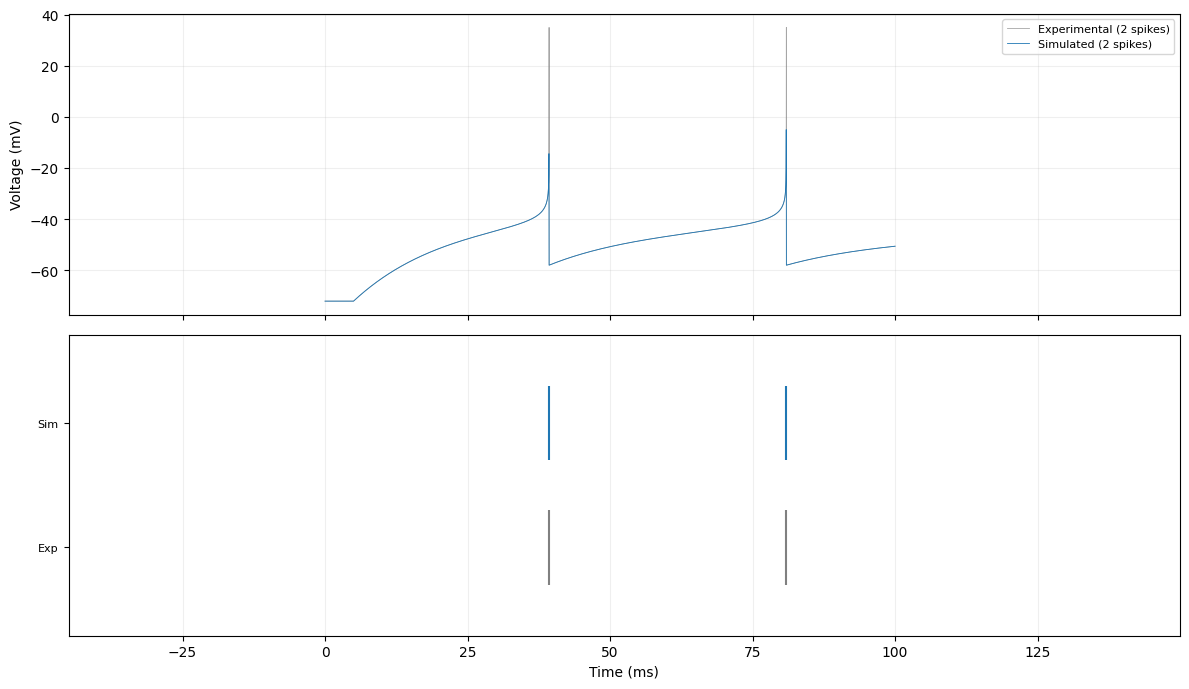

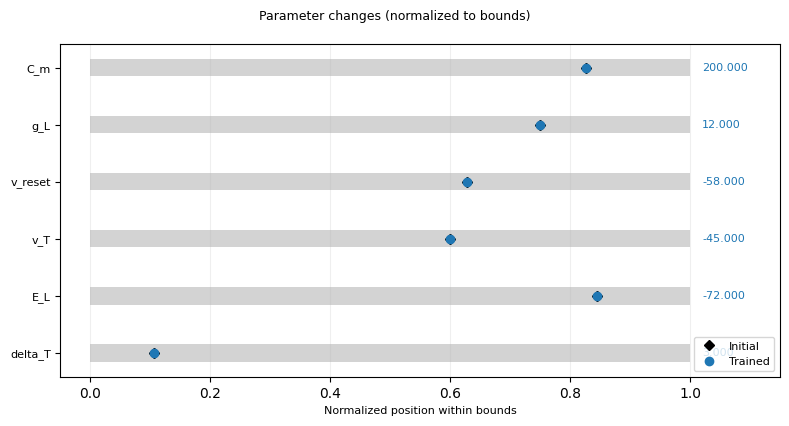

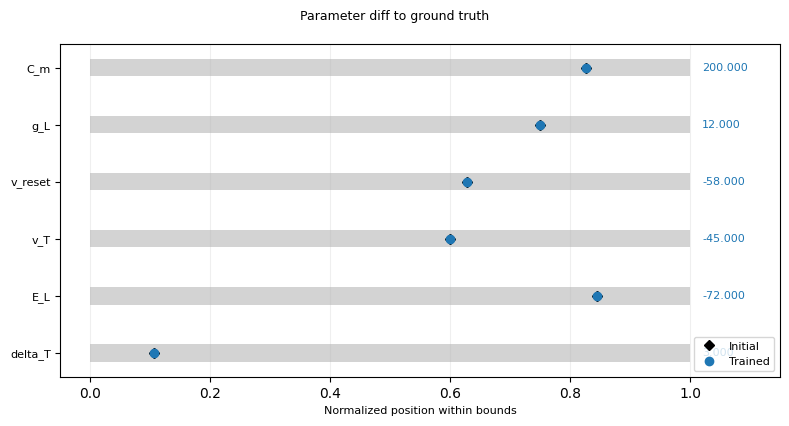

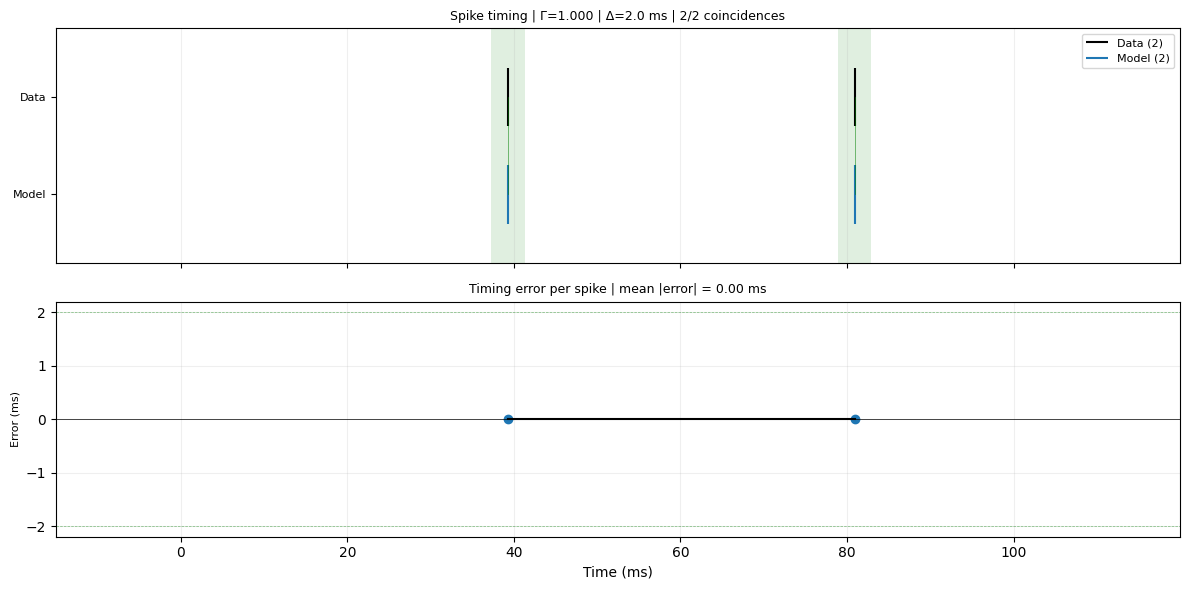

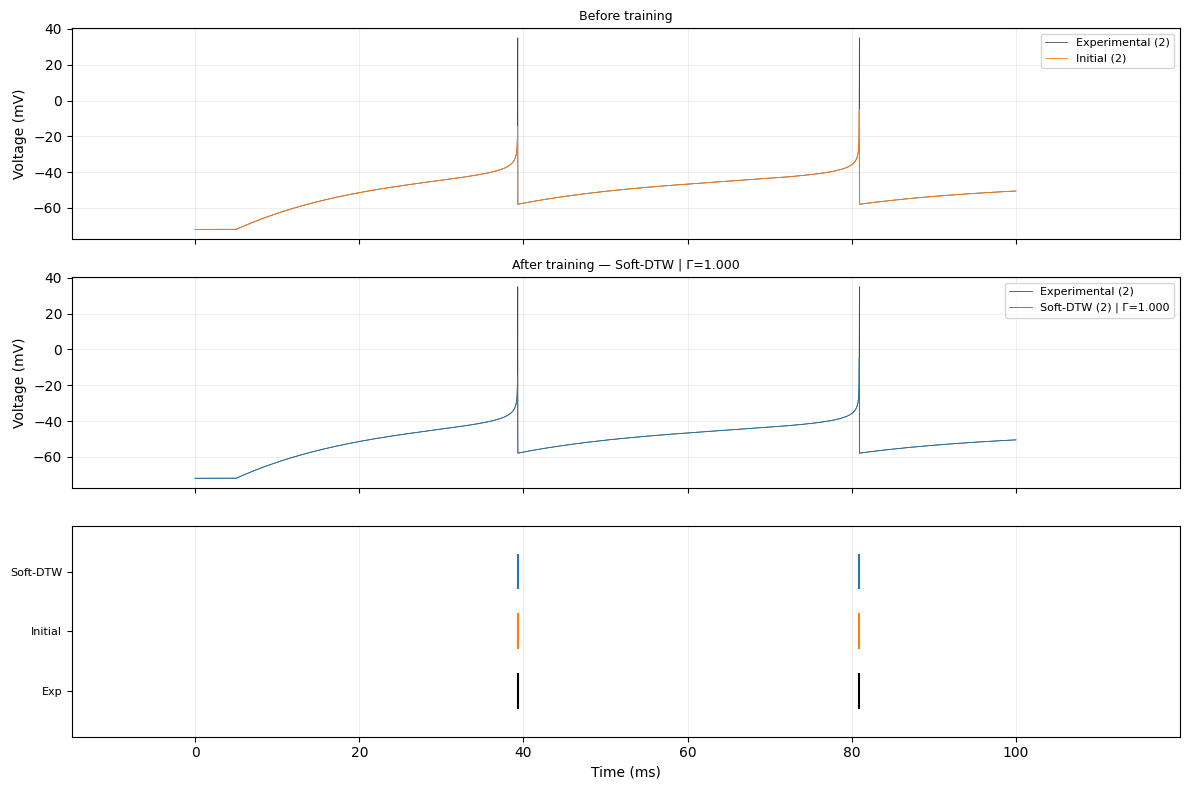

In [13]:
# --- Evaluate result ---
params_after = dict(initial_params)
params_after.update(result_stage1.get_params_dict())

sim_stage1 = simulate_with_current_trace(
    params=params_after,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1);
parameter_comparison_plot(TrainingResult(
    trainable_params=result_stage1.trainable_params,
    loss_history=result_stage1.loss_history,
    time_per_epoch=result_stage1.time_per_epoch,
    config=result_stage1.config,
    initial_params=ground_truth_params), figtitle="Parameter diff to ground truth");

if cf_s1 is not None:
    spike_timing_plot(data, sim_stage1, cf_s1);

fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1],
    coincidence=[cf_s1],
    labels=["Soft-DTW"],
);